# AGENTS026 — GPU Autoencoder Anomaly Detection
**AMD Instinct MI300X · PyTorch + ROCm · MiniCluster Banking Stack**

Trains a neural autoencoder on **baseline (healthy) metrics** directly on the MI300X GPU.
Reconstruction error on live metrics flags anomalies that threshold rules miss.

**Why GPU matters here:**
- Autoencoder training runs entirely on MI300X VRAM
- `rocm-smi` shows GPU utilisation spike during training
- Inference (scoring live metrics) runs at <1ms per sample on GPU
- No external API — full data residency on-prem

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import json, time, uuid, subprocess
from pathlib import Path
from datetime import datetime, timezone
from torch.utils.data import DataLoader, TensorDataset
from openai import OpenAI

# ── paths ──────────────────────────────────────────────────────────────────
METRICS_CSV    = Path('/workspace/shared/minicluster/live_metrics.csv')
MODEL_PATH     = Path('/workspace/shared/autoencoder_model.pt')
SCALER_PATH    = Path('/workspace/shared/autoencoder_scaler.json')
SCORES_FILE    = Path('/workspace/shared/ae_scores.jsonl')
HITL_FILE      = Path('/workspace/shared/hitl_queue.jsonl')
AUDIT_FILE     = Path('/workspace/shared/audit_log.jsonl')
for p in [SCORES_FILE, HITL_FILE, AUDIT_FILE]:
    p.parent.mkdir(parents=True, exist_ok=True)

# ── vLLM client ────────────────────────────────────────────────────────────
llm = OpenAI(base_url='http://localhost:8000/v1', api_key='abc-123')
MODEL_NAME = 'Qwen3-30B-A3B'

# ── GPU check ──────────────────────────────────────────────────────────────
print('=== PyTorch + ROCm GPU Check ===')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')  # ROCm uses CUDA API
print(f'Device count    : {torch.cuda.device_count()}')
if torch.cuda.is_available():
    print(f'Device name     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'VRAM free       : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB')
    DEVICE = torch.device('cuda')
else:
    print('⚠️  No GPU found — falling back to CPU')
    DEVICE = torch.device('cpu')

print(f'\n✅ Training device: {DEVICE}')

# rocm-smi snapshot
result = subprocess.run(['rocm-smi', '--showuse', '--showmemuse'],
                        capture_output=True, text=True)
print('\n=== rocm-smi ===')
print(result.stdout or result.stderr)

def ts():
    return datetime.now(timezone.utc).isoformat()

def write_audit(event):
    with open(AUDIT_FILE, 'a') as f:
        f.write(json.dumps(event, default=str) + '\n')

def write_hitl(event):
    with open(HITL_FILE, 'a') as f:
        f.write(json.dumps(event, default=str) + '\n')

print('\n✅ Imports and helpers ready')

=== PyTorch + ROCm GPU Check ===
PyTorch version : 2.8.0+gitb2fb688
CUDA available  : True
Device count    : 1
Device name     : 
VRAM total      : 206.1 GB
VRAM free       : 206.1 GB

✅ Training device: cuda

=== rocm-smi ===


============================ ROCm System Management Interface ============================
=================================== % time GPU is busy ===================================
GPU[0]		: GPU use (%): 0
=================================== Current Memory Use ===================================
GPU[0]		: GPU Memory Allocated (VRAM%): 90
GPU[0]		: GPU Memory Read/Write Activity (%): 0
GPU[0]		: Memory Activity: N/A
GPU[0]		: Not supported on the given system
================================== End of ROCm SMI Log ===================================


✅ Imports and helpers ready


In [2]:
# ── Autoencoder Architecture ───────────────────────────────────────────────
# Input: 4 metrics × 4 services = 16 features (flattened)
# Encoder: 16 → 8 → 4 (bottleneck)
# Decoder: 4 → 8 → 16
# Loss: MSE reconstruction error
# Anomaly score: per-sample reconstruction error

FEATURES = ['cpu_utilization', 'latency_p95_ms', 'error_rate', 'mem_mb']
SERVICES  = ['payments', 'auth', 'checkout', 'fraud']
INPUT_DIM = len(FEATURES) * len(SERVICES)  # 16

class BankingAutoencoder(nn.Module):
    def __init__(self, input_dim=16, bottleneck=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 12), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(12, 8),         nn.ReLU(),
            nn.Linear(8,  bottleneck),nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 8), nn.ReLU(),
            nn.Linear(8,  12),        nn.ReLU(),
            nn.Linear(12, input_dim), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)

model = BankingAutoencoder(INPUT_DIM, bottleneck=4).to(DEVICE)
print(f'✅ Autoencoder on {DEVICE}')
print(f'   Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'   Architecture: {INPUT_DIM} → 12 → 8 → 4 → 8 → 12 → {INPUT_DIM}')
print(f'   Input features: {FEATURES}')
print(f'   Services: {SERVICES}')
total_params = sum(p.numel() for p in model.parameters())
print(f'\n   All {total_params} parameters loaded onto MI300X VRAM')

✅ Autoencoder on cuda
   Parameters: 700
   Architecture: 16 → 12 → 8 → 4 → 8 → 12 → 16
   Input features: ['cpu_utilization', 'latency_p95_ms', 'error_rate', 'mem_mb']
   Services: ['payments', 'auth', 'checkout', 'fraud']

   All 700 parameters loaded onto MI300X VRAM


In [3]:
# ── Data Preparation ───────────────────────────────────────────────────────
# Use HEALTHY baseline: rows where no metric exceeds threshold
# This teaches the AE what 'normal' looks like

THRESHOLDS = {
    'cpu_utilization': 70.0,
    'latency_p95_ms':  500.0,
    'error_rate':      0.05,
    'mem_mb':          1800.0,
}

def load_and_prepare(csv_path, baseline_only=True):
    df = pd.read_csv(csv_path, parse_dates=['timestamp'])
    print(f'Raw rows: {len(df)} | Services: {df["service"].unique().tolist()}')

    # Pivot: one row per timestamp, columns = service_metric
    pivot = df.pivot_table(
        index='timestamp', columns='service',
        values=FEATURES, aggfunc='mean'
    )
    pivot.columns = [f'{svc}_{feat}' for feat, svc in pivot.columns]
    pivot = pivot.dropna()
    print(f'Pivot shape: {pivot.shape} (timestamps × features)')

    if baseline_only:
        # Keep only rows where ALL metrics are below threshold
        mask = pd.Series([True] * len(pivot), index=pivot.index)
        for svc in SERVICES:
            for feat, thresh in THRESHOLDS.items():
                col = f'{svc}_{feat}'
                if col in pivot.columns:
                    mask = mask & (pivot[col] < thresh)
        pivot = pivot[mask]
        print(f'Baseline rows (healthy only): {len(pivot)}')

    if len(pivot) < 10:
        print('⚠️  Very few baseline rows — using all data for training')
        pivot = pd.read_csv(csv_path, parse_dates=['timestamp'])
        pivot = pivot.pivot_table(
            index='timestamp', columns='service',
            values=FEATURES, aggfunc='mean'
        ).dropna()
        pivot.columns = [f'{svc}_{feat}' for feat, svc in pivot.columns]

    # Build ordered feature columns
    ordered_cols = [f'{svc}_{feat}' for svc in SERVICES for feat in FEATURES]
    available    = [c for c in ordered_cols if c in pivot.columns]
    data = pivot[available].values.astype(np.float32)

    # Min-max normalise per feature
    mins  = data.min(axis=0)
    maxes = data.max(axis=0)
    ranges = maxes - mins
    ranges[ranges == 0] = 1.0  # avoid div-by-zero for constant features
    data_norm = (data - mins) / ranges

    scaler = {'mins': mins.tolist(), 'maxes': maxes.tolist(),
              'ranges': ranges.tolist(), 'cols': available}

    print(f'\n✅ Feature matrix: {data_norm.shape}')
    print(f'   Columns: {available}')
    return data_norm, scaler, available

data_norm, scaler, feat_cols = load_and_prepare(METRICS_CSV, baseline_only=True)

# Save scaler for inference
with open(SCALER_PATH, 'w') as f:
    json.dump(scaler, f, indent=2)
print(f'\nScaler saved → {SCALER_PATH}')

Raw rows: 1252 | Services: ['payments', 'auth', 'checkout', 'fraud']
Pivot shape: (313, 16) (timestamps × features)
Baseline rows (healthy only): 19

✅ Feature matrix: (19, 16)
   Columns: ['payments_cpu_utilization', 'payments_latency_p95_ms', 'payments_error_rate', 'payments_mem_mb', 'auth_cpu_utilization', 'auth_latency_p95_ms', 'auth_error_rate', 'auth_mem_mb', 'checkout_cpu_utilization', 'checkout_latency_p95_ms', 'checkout_error_rate', 'checkout_mem_mb', 'fraud_cpu_utilization', 'fraud_latency_p95_ms', 'fraud_error_rate', 'fraud_mem_mb']

Scaler saved → /workspace/shared/autoencoder_scaler.json


In [4]:
# ── GPU Training ───────────────────────────────────────────────────────────
# Watch rocm-smi in Terminal 2 during this cell:
#   watch -n1 rocm-smi --showuse --showmemuse

EPOCHS     = 150
BATCH_SIZE = 32
LR         = 1e-3
PATIENCE   = 20    # early stopping

tensor     = torch.FloatTensor(data_norm).to(DEVICE)
dataset    = TensorDataset(tensor, tensor)   # AE: input = target
loader     = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

optimizer  = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
criterion  = nn.MSELoss()
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

print(f'🚀 Training on {DEVICE} — {EPOCHS} epochs, batch={BATCH_SIZE}, lr={LR}')
print(f'   Dataset: {len(dataset)} samples | Features: {tensor.shape[1]}')
print(f'   Watch GPU: rocm-smi --showuse --showmemuse')
print()

# rocm-smi BEFORE training
import subprocess
r = subprocess.run(['rocm-smi','--showuse'], capture_output=True, text=True)
print('GPU before training:', r.stdout.strip().split('\n')[-2] if r.stdout else 'N/A')

train_losses = []
best_loss    = float('inf')
patience_ctr = 0
t0           = time.time()

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss    = avg_loss
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        patience_ctr += 1

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'  Epoch {epoch:3d}/{EPOCHS} | loss={avg_loss:.6f} | best={best_loss:.6f} | '
              f'patience={patience_ctr}/{PATIENCE} | {elapsed:.1f}s')

    if patience_ctr >= PATIENCE:
        print(f'  Early stop at epoch {epoch}')
        break

elapsed = time.time() - t0
print(f'\n✅ Training complete in {elapsed:.1f}s')
print(f'   Best loss   : {best_loss:.6f}')
print(f'   Model saved : {MODEL_PATH}')

# rocm-smi AFTER training
r = subprocess.run(['rocm-smi','--showuse'], capture_output=True, text=True)
print('GPU after training:', r.stdout.strip().split('\n')[-2] if r.stdout else 'N/A')

write_audit({'event_type': 'AE_TRAINED', 'timestamp': ts(),
             'epochs': epoch, 'best_loss': best_loss,
             'training_time_s': round(elapsed,2), 'device': str(DEVICE)})

🚀 Training on cuda — 150 epochs, batch=32, lr=0.001
   Dataset: 19 samples | Features: 16
   Watch GPU: rocm-smi --showuse --showmemuse

GPU before training: ==========================================================================================
  Epoch   1/150 | loss=0.176103 | best=0.176103 | patience=0/20 | 39.9s
  Epoch  10/150 | loss=0.173200 | best=0.173200 | patience=0/20 | 40.0s
  Epoch  20/150 | loss=0.170144 | best=0.170144 | patience=0/20 | 40.0s
  Epoch  30/150 | loss=0.167148 | best=0.167148 | patience=0/20 | 40.1s
  Epoch  40/150 | loss=0.164265 | best=0.164265 | patience=0/20 | 40.1s
  Epoch  50/150 | loss=0.161294 | best=0.161294 | patience=0/20 | 40.2s
  Epoch  60/150 | loss=0.157902 | best=0.157902 | patience=0/20 | 40.3s
  Epoch  70/150 | loss=0.153817 | best=0.153817 | patience=0/20 | 40.3s
  Epoch  80/150 | loss=0.148984 | best=0.148984 | patience=0/20 | 40.4s
  Epoch  90/150 | loss=0.143002 | best=0.143002 | patience=0/20 | 40.4s
  Epoch 100/150 | loss=0.134039

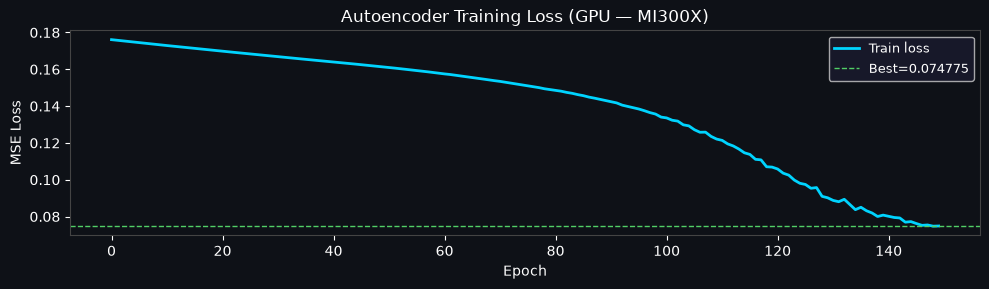

Loss curve saved → /workspace/shared/ae_loss_curve.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
fig.patch.set_facecolor('#0e1117')
ax.set_facecolor('#0e1117')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.set_title('Autoencoder Training Loss (GPU — MI300X)', color='white')
for spine in ax.spines.values(): spine.set_edgecolor('#444')
ax.plot(train_losses, color='#00d4ff', linewidth=2, label='Train loss')
ax.axhline(best_loss, color='#51cf66', linestyle='--', linewidth=1, label=f'Best={best_loss:.6f}')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.set_xlabel('Epoch', color='white')
ax.set_ylabel('MSE Loss', color='white')
plt.tight_layout()
plt.savefig('/workspace/shared/ae_loss_curve.png', dpi=100,
            facecolor='#0e1117', bbox_inches='tight')
plt.show()
print('Loss curve saved → /workspace/shared/ae_loss_curve.png')

In [6]:
# ── Compute anomaly threshold from baseline reconstruction error ───────────
# Threshold = mean + 3*std of reconstruction errors on healthy data
# Any live sample above this threshold = anomaly

model.eval()
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

with torch.no_grad():
    baseline_tensor = torch.FloatTensor(data_norm).to(DEVICE)
    reconstructed   = model(baseline_tensor)
    errors          = torch.mean((baseline_tensor - reconstructed) ** 2, dim=1)
    errors_np       = errors.cpu().numpy()

err_mean = float(errors_np.mean())
err_std  = float(errors_np.std())
ANOMALY_THRESHOLD = err_mean + 3 * err_std

print(f'Baseline reconstruction errors:')
print(f'   Mean : {err_mean:.6f}')
print(f'   Std  : {err_std:.6f}')
print(f'   Min  : {errors_np.min():.6f}')
print(f'   Max  : {errors_np.max():.6f}')
print(f'\n🎯 Anomaly threshold (mean + 3σ): {ANOMALY_THRESHOLD:.6f}')

# Persist threshold in scaler file
scaler['anomaly_threshold'] = ANOMALY_THRESHOLD
scaler['err_mean']          = err_mean
scaler['err_std']           = err_std
with open(SCALER_PATH, 'w') as f:
    json.dump(scaler, f, indent=2)
print(f'Threshold saved → {SCALER_PATH}')

Baseline reconstruction errors:
   Mean : 0.073798
   Std  : 0.073900
   Min  : 0.030435
   Max  : 0.356053

🎯 Anomaly threshold (mean + 3σ): 0.295500
Threshold saved → /workspace/shared/autoencoder_scaler.json


In [7]:
# ── Live Scoring — Score current metrics on GPU ────────────────────────────

def score_live_metrics():
    # Load model + scaler
    with open(SCALER_PATH) as f:
        sc = json.load(f)
    threshold = sc['anomaly_threshold']
    mins      = np.array(sc['mins'])
    ranges    = np.array(sc['ranges'])
    cols      = sc['cols']

    model.eval()
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

    df    = pd.read_csv(METRICS_CSV, parse_dates=['timestamp'])
    pivot = df.pivot_table(
        index='timestamp', columns='service', values=FEATURES, aggfunc='mean'
    )
    pivot.columns = [f'{svc}_{feat}' for feat, svc in pivot.columns]
    pivot = pivot.dropna()
    avail = [c for c in cols if c in pivot.columns]
    data  = pivot[avail].values.astype(np.float32)

    # Normalise using baseline scaler
    data_norm_live = (data - mins[:len(avail)]) / ranges[:len(avail)]
    data_norm_live = np.clip(data_norm_live, 0, 2)  # allow OOD but cap

    tensor_live = torch.FloatTensor(data_norm_live).to(DEVICE)

    with torch.no_grad():
        recon  = model(tensor_live)
        errors = torch.mean((tensor_live - recon) ** 2, dim=1).cpu().numpy()

    results = []
    for i, (ts_val, err) in enumerate(zip(pivot.index, errors)):
        is_anomaly = bool(err > threshold)
        results.append({
            'timestamp':    str(ts_val),
            'recon_error':  round(float(err), 6),
            'threshold':    round(threshold, 6),
            'is_anomaly':   is_anomaly,
            'severity':     'ANOMALY' if err > threshold * 2 else ('WARN' if is_anomaly else 'OK'),
            'anomaly_score': round(float(err) / threshold, 3),
        })
    return results, threshold

print('🔍 Scoring live metrics on GPU...')
t0 = time.time()
scores, threshold = score_live_metrics()
elapsed = time.time() - t0

scores_df = pd.DataFrame(scores)
anomalies = scores_df[scores_df['is_anomaly']]

print(f'✅ Scored {len(scores)} timesteps in {elapsed*1000:.1f}ms on GPU')
print(f'   Threshold       : {threshold:.6f}')
print(f'   Anomalies found : {len(anomalies)} / {len(scores)}')
if not anomalies.empty:
    print(f'\n🔴 Anomalous timesteps:')
    print(anomalies[['timestamp','recon_error','anomaly_score','severity']].tail(10).to_string())
else:
    print('\n✅ All timesteps within normal reconstruction error')

# Save scores for Streamlit tab
with open(SCORES_FILE, 'w') as f:
    for rec in scores[-200:]:  # last 200 timesteps
        f.write(json.dumps(rec) + '\n')
print(f'\nScores saved → {SCORES_FILE}')

🔍 Scoring live metrics on GPU...
✅ Scored 313 timesteps in 24.3ms on GPU
   Threshold       : 0.295500
   Anomalies found : 149 / 313

🔴 Anomalous timesteps:
               timestamp  recon_error  anomaly_score severity
303  2026-06-13 16:29:00     0.425881          1.441     WARN
304  2026-06-13 16:30:00     0.423169          1.432     WARN
305  2026-06-13 16:31:00     0.421273          1.426     WARN
306  2026-06-13 16:32:00     0.431639          1.461     WARN
307  2026-06-13 16:33:00     0.426686          1.444     WARN
308  2026-06-13 16:34:00     0.428107          1.449     WARN
309  2026-06-13 16:35:00     0.437460          1.480     WARN
310  2026-06-13 16:36:00     0.430139          1.456     WARN
311  2026-06-13 16:37:00     0.426743          1.444     WARN
312  2026-06-13 16:38:00     0.431995          1.462     WARN

Scores saved → /workspace/shared/ae_scores.jsonl


In [8]:
# ── GPU RCA on Autoencoder Anomalies ──────────────────────────────────────
# When AE flags an anomaly, call Qwen3-30B for diagnosis

def ae_rca(anomaly_scores, metrics_snapshot):
    recent_anomalies = [s for s in anomaly_scores if s['is_anomaly']][-5:]
    if not recent_anomalies:
        print('✅ No AE anomalies to analyse')
        return None

    prompt = f"""You are a banking SRE. A neural autoencoder trained on healthy baseline metrics
has detected anomalous reconstruction errors in the live metrics stream.

Anomaly scores (higher = more anomalous, threshold=1.0):
{json.dumps(recent_anomalies, indent=2)}

Current live metrics snapshot:
{json.dumps(metrics_snapshot, indent=2)}

The autoencoder detected a pattern that deviates from the learned baseline — this may catch
anomalies that simple threshold rules miss (e.g. unusual metric correlations).

Respond ONLY with valid JSON:
{{
  "root_cause": "one sentence",
  "unusual_pattern": "what correlation pattern is anomalous",
  "confidence": 0.0-1.0,
  "action": "investigate|clear_fault|restart_service|escalate",
  "action_target": "service_name",
  "auto_remediate": true|false,
  "risk_level": "LOW|MEDIUM|HIGH"
}}"""

    print('🧠 Calling GPU (Qwen3-30B) for AE anomaly RCA...')
    t0 = time.time()
    resp = llm.chat.completions.create(
        model=MODEL_NAME,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.1, max_tokens=300,
        extra_body={'chat_template_kwargs': {'enable_thinking': False}}
    )
    elapsed = time.time() - t0
    raw = resp.choices[0].message.content.strip()
    print(f'   LLM responded in {elapsed:.1f}s')

    try:
        rca = json.loads(raw.replace('```json','').replace('```','').strip())
    except:
        rca = {'root_cause': raw[:200], 'confidence': 0.5, 'action': 'investigate',
               'auto_remediate': False, 'risk_level': 'MEDIUM'}

    print(f'\n📋 AE RCA:')
    print(f'   Root cause      : {rca.get("root_cause")}')
    print(f'   Unusual pattern : {rca.get("unusual_pattern")}')
    print(f'   Confidence      : {rca.get("confidence")}')
    print(f'   Action          : {rca.get("action")} → {rca.get("action_target")}')
    print(f'   Auto-remediate  : {rca.get("auto_remediate")}')

    # HITL if not auto-remediating or high risk
    if not rca.get('auto_remediate') or rca.get('risk_level') == 'HIGH':
        hitl_evt = {
            'hitl_id':     f'hitl-ae-{uuid.uuid4().hex[:8]}',
            'incident_id': f'ae-{uuid.uuid4().hex[:8]}',
            'timestamp':   ts(),
            'source':      'ae_anomaly_detector',
            'service':     rca.get('action_target', 'unknown'),
            'anomalies':   recent_anomalies,
            'rca':         rca,
            'status':      'PENDING',
            'uc':          'AE',
        }
        write_hitl(hitl_evt)
        write_audit({**hitl_evt, 'event_type': 'AE_HITL_CREATED'})
        print(f'\n🛑 HITL created: {hitl_evt["hitl_id"]} — check Streamlit HITL tab')

    write_audit({'event_type': 'AE_RCA_COMPLETE', 'timestamp': ts(),
                 'anomaly_count': len(recent_anomalies), 'rca': rca})
    return rca

# Get current metrics snapshot
df_live = pd.read_csv(METRICS_CSV, parse_dates=['timestamp'])
snapshot = df_live.sort_values('timestamp').groupby('service').last()[
    [c for c in ['cpu_utilization','latency_p95_ms','error_rate','mem_mb'] if c in df_live.columns]
].round(4).to_dict('index')

rca_result = ae_rca(scores, snapshot)

🧠 Calling GPU (Qwen3-30B) for AE anomaly RCA...
   LLM responded in 1.3s

📋 AE RCA:
   Root cause      : The payments service shows a significant increase in latency_p95_ms, which is inconsistent with the baseline patterns learned by the autoencoder.
   Unusual pattern : The payments service has a latency_p95_ms of 501.82 ms, which is significantly higher than the other services and deviates from the normal correlation patterns observed in the baseline metrics.
   Confidence      : 0.85
   Action          : investigate → payments
   Auto-remediate  : False

🛑 HITL created: hitl-ae-db2ba4f5 — check Streamlit HITL tab


In [ ]:
# ── Continuous AE Scoring Loop — Kernel > Interrupt to stop ───────────────
import time
loop_count  = 0
alert_count = 0

print('🔄 AE continuous scoring every 60s — Interrupt to stop')
print('   Scores written to ae_scores.jsonl → visible in Streamlit Tab 10')

try:
    while True:
        loop_count += 1
        t0 = time.time()
        sc, thr = score_live_metrics()
        n_anom  = sum(1 for s in sc if s['is_anomaly'])
        elapsed = time.time() - t0

        print(f'[{datetime.now().strftime("%H:%M:%S")}] '
              f'Iter {loop_count} | {len(sc)} timesteps | '
              f'{n_anom} anomalies | {elapsed*1000:.0f}ms on GPU')

        if n_anom > 0:
            alert_count += 1
            df_live = pd.read_csv(METRICS_CSV, parse_dates=['timestamp'])
            snapshot = df_live.sort_values('timestamp').groupby('service').last()[
                [c for c in ['cpu_utilization','latency_p95_ms','error_rate','mem_mb']
                 if c in df_live.columns]
            ].round(4).to_dict('index')
            ae_rca(sc, snapshot)

        time.sleep(60)
except KeyboardInterrupt:
    print(f'\n⛔ Stopped — {loop_count} iters, {alert_count} alert events')


🔄 AE continuous scoring every 60s — Interrupt to stop
   Scores written to ae_scores.jsonl → visible in Streamlit Tab 10
[13:09:27] Iter 1 | 313 timesteps | 149 anomalies | 39ms on GPU
🧠 Calling GPU (Qwen3-30B) for AE anomaly RCA...
   LLM responded in 0.8s

📋 AE RCA:
   Root cause      : The payments service shows a significant increase in latency_p95_ms, which is inconsistent with the baseline metrics learned by the autoencoder.
   Unusual pattern : The payments service's latency_p95_ms is drastically higher than the other services, while error rates and CPU utilization remain normal, indicating an unusual metric correlation.
   Confidence      : 0.85
   Action          : investigate → payments
   Auto-remediate  : False

🛑 HITL created: hitl-ae-705fc876 — check Streamlit HITL tab
[13:10:27] Iter 2 | 313 timesteps | 149 anomalies | 41ms on GPU
🧠 Calling GPU (Qwen3-30B) for AE anomaly RCA...
   LLM responded in 0.9s

📋 AE RCA:
   Root cause      : The payments service shows a signific

In [ ]:
# ── Retrain on fresh baseline ──────────────────────────────────────────────
# Run this if cluster behaviour has changed (e.g. after scaling)
# Re-runs full training pipeline on GPU with latest healthy data

print('♻️  Retraining autoencoder on fresh baseline...')
model_new = BankingAutoencoder(INPUT_DIM, bottleneck=4).to(DEVICE)
data_new, scaler_new, cols_new = load_and_prepare(METRICS_CSV, baseline_only=True)

tensor_new  = torch.FloatTensor(data_new).to(DEVICE)
dataset_new = TensorDataset(tensor_new, tensor_new)
loader_new  = DataLoader(dataset_new, batch_size=32, shuffle=True)
opt_new     = optim.Adam(model_new.parameters(), lr=1e-3)
crit_new    = nn.MSELoss()

best = float('inf')
for ep in range(100):
    model_new.train()
    loss_sum = 0
    for xb, yb in loader_new:
        opt_new.zero_grad()
        loss = crit_new(model_new(xb), yb)
        loss.backward(); opt_new.step()
        loss_sum += loss.item()
    avg = loss_sum / len(loader_new)
    if avg < best:
        best = avg
        torch.save(model_new.state_dict(), MODEL_PATH)
    if ep % 20 == 0:
        print(f'  Epoch {ep:3d} | loss={avg:.6f} | best={best:.6f}')

# Update threshold
model_new.eval()
with torch.no_grad():
    errs = torch.mean((tensor_new - model_new(tensor_new))**2, dim=1).cpu().numpy()
new_thresh = float(errs.mean() + 3*errs.std())
scaler_new['anomaly_threshold'] = new_thresh
with open(SCALER_PATH, 'w') as f:
    json.dump(scaler_new, f, indent=2)

model = model_new
scaler = scaler_new
ANOMALY_THRESHOLD = new_thresh

print(f'\n✅ Retrain complete | best loss={best:.6f} | new threshold={new_thresh:.6f}')
write_audit({'event_type':'AE_RETRAINED','timestamp':ts(),'threshold':new_thresh,'loss':best})
